# Week 05: Stats for Business: Is the Price Right?

Mohamed Hiba

The template says Week 06, but this exercise is assigned in the Week 05 folder and syllabus.


You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# If needed, install these packages in your notebook environment:
# %pip install pandas numpy matplotlib scipy


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)
# Works when launched from this week's root, exercise/, or the repository root.
data_candidates = [Path("data/cars.csv"), Path("../data/cars.csv"),
                   Path("Week-05-Business-Stats-Analytics/data/cars.csv")]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Run from the repository, Week-05 folder, or its exercise folder.")
df = pd.read_csv(data_path)
print("Raw shape:", df.shape)
display(df.head())


Raw shape: (11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
print("Exact duplicate rows:", df.duplicated().sum())
display(df.isna().sum().to_frame("missing_raw"))
print("Most common prices:")
display(df["MSRP"].value_counts().head(10))
print("Years with the $2,000 floor:")
display(df.loc[df.MSRP.eq(2000)].groupby("Year").size())
print("Largest highway values and their fuel types:")
display(df.nlargest(8, "highway MPG")[["Make", "Model", "Year", "Engine Fuel Type", "highway MPG", "city mpg"]])
print("Largest prices (inspect rather than automatically deleting):")
display(df.nlargest(5, "MSRP")[["Make", "Model", "Year", "MSRP"]])
print("Missing horsepower by fuel type:")
display(df.groupby("Engine Fuel Type", dropna=False)["Engine HP"].agg(size="size", missing=lambda s: s.isna().sum()))
print("Distinct popularity values within each make:")
display(df.groupby("Make")["Popularity"].nunique().value_counts())


Exact duplicate rows: 720


,missing_raw
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Vehicle Size,0


Most common prices:


MSRP
2000     1036
25995      19
29995      19
20995      16
27995      16
30995      15
23995      15
24995      14
21995      14
26195      13
Name: count, dtype: int64

Years with the $2,000 floor:


...

,Make,Model,Year,MSRP
11362,Bugatti,Veyron 16.4,2008,2065902
11364,Bugatti,Veyron 16.4,2009,1705769
8486,Lamborghini,Reventon,2008,1500000
11363,Bugatti,Veyron 16.4,2008,1500000
6351,Maybach,Landaulet,2012,1382750


Missing horsepower by fuel type:


,size,missing
Engine Fuel Type,,
diesel,154,1
electric,66,44
flex-fuel (premium unleaded recommended/E85),26,0
flex-fuel (premium unleaded required/E85),54,0
flex-fuel (unleaded/E85),899,0
flex-fuel (unleaded/natural gas),6,6
natural gas,2,0
premium unleaded (recommended),1523,4
premium unleaded (required),2009,0


Distinct popularity values within each make:


Popularity
1    48
Name: count, dtype: int64

**Cleaning log:** Counts refer to the raw data unless the cleaned count is also stated. Flags overlap.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Exact repeated rows | `df.duplicated().sum()` | 720 surplus rows | Keep one copy of each exact row | Avoid counting identical records repeatedly; different trims with different specs remain |
| 2 | Suspicious $2,000 MSRP floor | Price frequency and years of those rows | 1,036 raw; 747 after deduplication | Preserve `msrp_raw`, flag, and set only `msrp` to NaN | All are 1990–2000 cars; the repeated minimum looks like a floor/censoring rule, not reliable sticker prices; this is a conservative assumption, not a verified correction |
| 3 | Implausible highway efficiency | Largest highway values, compared with city MPG | 1 Audi A6 (2017), 354 highway vs 24 city | Preserve raw value, flag, set highway MPG to NaN | Likely a data error; do not guess the intended value |
| 4 | Electric efficiency mixed with fuel MPG | Fuel type alongside extreme efficiency values | 66 electric rows | Retain records and prices; exclude electric efficiency from gallon-based comparisons | MPG-equivalent and gasoline MPG are different measures; electric cars are not errors |
| 5 | Missing specs and fuel type | Missing-value counts and HP missingness by fuel type | HP 69 (44 electric), cylinders 30, doors 6, fuel 3 | Leave missing values as NaN; exclude unknown fuel only from trusted MPG comparisons | Missingness is not random; filling HP with an overall mean would hide powertrain differences; an incomplete row can still have a valid price |
| 6 | Popularity is measured at make level | Each make has exactly one distinct popularity value | All 11,194 retained rows, across 48 makes | Leave it; flag in this log as a make-level attribute | It cannot measure differences in popularity between trims of the same brand |
| 7 | Extreme luxury prices | Largest MSRP records include Bugatti, Lamborghini and Maybach | 6 raw rows above $1 million | Retain and use robust summaries/log plots | Unusual does not mean erroneous; arbitrarily removing luxury cars would change the question |
| 8 | Mixed years and uncertain price comparability | Year distribution by transmission | 5,434 retained rows before 2015 | Flag older rows; use 2015–2017 for the adjusted comparison | Vintage, inflation and possibly used-price conventions can confound pooled prices; the file alone cannot confirm price provenance |

I retain 11,194 of 11,914 rows and only remove exact duplicates. Price summaries exclude the suspect floor, so they describe the 10,447 remaining valid-price records rather than every original row. Exact matches could still represent distinct trims whose identifying fields were omitted; deduplication is an explicit assumption.


In [4]:
clean = df.drop_duplicates().copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
# Keep the source values for auditing; do not guess replacement measurements.
clean["msrp_raw"] = clean["msrp"]
clean["price_floor_flag"] = clean.msrp.eq(2000)
clean.loc[clean.price_floor_flag, "msrp"] = np.nan
clean["older_price_flag"] = clean.year.lt(2015)
clean["electric_flag"] = clean.engine_fuel_type.eq("electric")
clean["unknown_fuel_flag"] = clean.engine_fuel_type.isna()
clean["highway_mpg_raw"] = clean.highway_mpg
# Flag the isolated 354 value, which is implausible and inconsistent with its city MPG.
clean["highway_error_flag"] = clean.highway_mpg.eq(354)
clean.loc[clean.highway_error_flag, "highway_mpg"] = np.nan
# Separate physical MPG from electric MPG-equivalent; retain all rows for prices.
clean["mpg_trusted"] = (~clean.electric_flag & ~clean.unknown_fuel_flag &
                        ~clean.highway_error_flag & clean.highway_mpg.gt(0))
clean["highway_mpg_trusted"] = clean.highway_mpg.where(clean.mpg_trusted)
# Missing HP/cylinders/doors stay missing. Zero cylinders on EVs are meaningful.
print("Clean shape:", clean.shape)
print("Flags after deduplication:")
display(clean[["price_floor_flag", "older_price_flag", "electric_flag", "unknown_fuel_flag", "highway_error_flag"]].sum().to_frame("rows"))
print("Rows with any originally missing field:", df.drop_duplicates().isna().any(axis=1).sum())


Clean shape: (11194, 24)
Flags after deduplication:


,rows
price_floor_flag,747
older_price_flag,5434
electric_flag,66
unknown_fuel_flag,3
highway_error_flag,1


Rows with any originally missing field: 102


In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 24)
engine_fuel_type         3
engine_hp               69
engine_cylinders        30
number_of_doors          6
highway_mpg              1
msrp                   747
highway_mpg_trusted     70
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Valid prices: 10,447; mean $44,788.67; median $31,870.00
Above mean: 24.45%


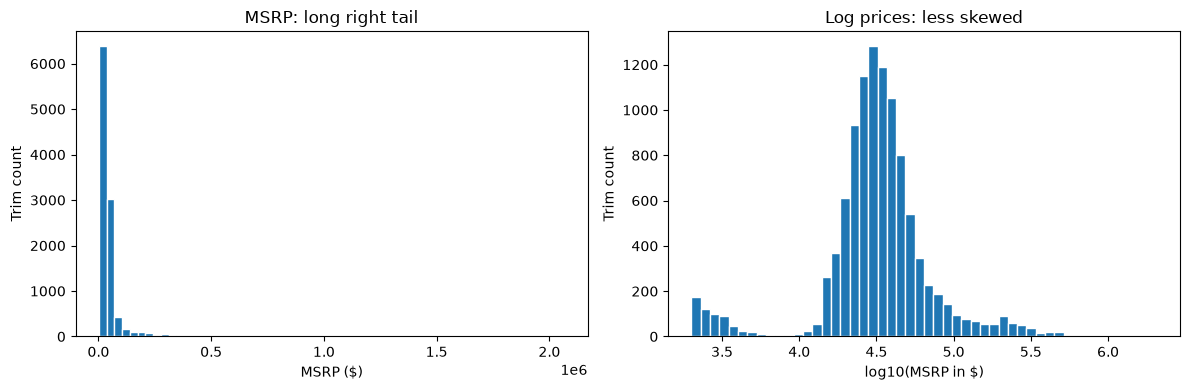

In [6]:
prices = clean.msrp.dropna()
price_mean, price_median = prices.mean(), prices.median()
above_mean_pct = 100 * prices.gt(price_mean).mean()
print(f"Valid prices: {len(prices):,}; mean ${price_mean:,.2f}; median ${price_median:,.2f}")
print(f"Above mean: {above_mean_pct:.2f}%")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices, bins=60, edgecolor="white")
axes[0].set(xlabel="MSRP ($)", ylabel="Trim count", title="MSRP: long right tail")
axes[1].hist(np.log10(prices), bins=50, edgecolor="white")
axes[1].set(xlabel="log10(MSRP in $)", ylabel="Trim count", title="Log prices: less skewed")
plt.tight_layout()
plt.show()


**Answer:** The mean is $44,788.67 and the median is $31,870; expensive luxury trims pull the mean upward, and only 24.45% of valid prices exceed it. Raw MSRP has a long right tail, while log10 prices are much less skewed with more than one concentration rather than a perfect bell curve. I would use the median on the homepage, labeled as the median listed trim price in this historical dataset, because it is less affected by extreme prices and does not imply current transaction prices.


### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [7]:
cars2017 = clean.loc[clean.year.eq(2017)]
size_stats = cars2017.groupby("vehicle_size").highway_mpg_trusted.agg(["count", "mean", "std"])
display(size_stats)
z_civic = (42 - size_stats.loc["Compact", "mean"]) / size_stats.loc["Compact", "std"]
z_s90 = (34 - size_stats.loc["Large", "mean"]) / size_stats.loc["Large", "std"]
print(f"Civic z-score: {z_civic:.3f}; S90 z-score: {z_s90:.3f}")


,count,mean,std
vehicle_size,,,
Compact,509,30.880157,6.045381
Large,468,22.991453,3.491184
Midsize,638,29.410658,5.452292


Civic z-score: 1.839; S90 z-score: 3.153


**Answer:** Among trusted 2017 values, Compact cars average 30.88 highway MPG (SD 6.05), Large cars 22.99 (SD 3.49), and Midsize cars 29.41 (SD 5.45). The Civic is 1.84 SD above its class mean, while the S90 is 3.15 SD above its class mean, making the Volvo more impressive relative to its class despite lower raw MPG. These are descriptive measures of unusualness; the class distributions are not guaranteed normal, so z-scores alone do not give exact tail probabilities.


---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

All 2017: n=1624, median=$36,738, CI=[35940.     37682.5625], width=$1,743
Volvo: n=23, median=$46,350, CI=[41750. 50450.], width=$8,700


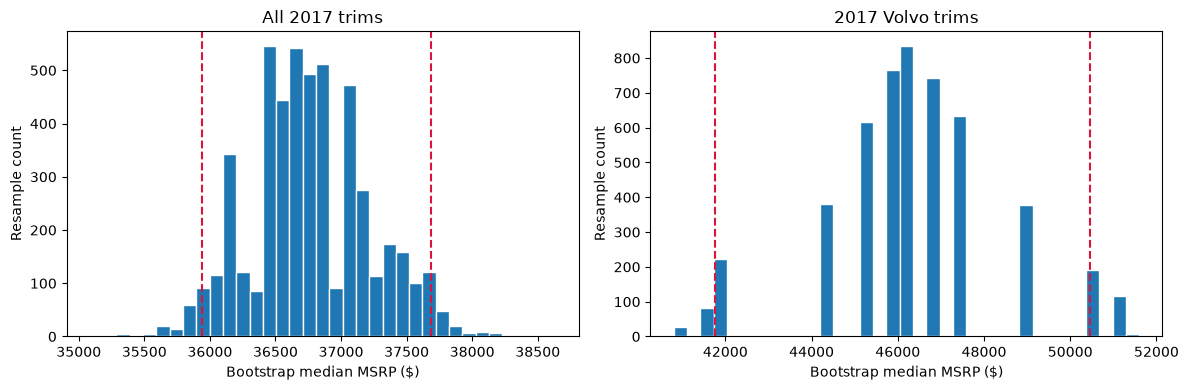

In [8]:
def bootstrap_median(values, n_boot=5000):
    """Resample valid prices with replacement, using the shared seeded rng."""
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        raise ValueError("Need at least one valid price")
    return np.array([np.median(rng.choice(values, size=len(values), replace=True))
                     for _ in range(n_boot)])

prices2017 = cars2017.msrp.dropna()
boot_all = bootstrap_median(prices2017)
ci_all = np.percentile(boot_all, [2.5, 97.5])
# Volvo has fewer than 50 trims and more than one observation.
small_make = "Volvo"
small_prices = cars2017.loc[cars2017.make.eq(small_make), "msrp"].dropna()
assert 1 < len(small_prices) < 50
boot_small = bootstrap_median(small_prices)
ci_small = np.percentile(boot_small, [2.5, 97.5])
print(f"All 2017: n={len(prices2017)}, median=${prices2017.median():,.0f}, CI={ci_all}, width=${np.diff(ci_all)[0]:,.0f}")
print(f"{small_make}: n={len(small_prices)}, median=${small_prices.median():,.0f}, CI={ci_small}, width=${np.diff(ci_small)[0]:,.0f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, values, interval, title in zip(axes, [boot_all, boot_small], [ci_all, ci_small], ["All 2017 trims", "2017 Volvo trims"]):
    ax.hist(values, bins=35, edgecolor="white")
    for bound in interval:
        ax.axvline(bound, color="crimson", linestyle="--")
    ax.set(xlabel="Bootstrap median MSRP ($)", ylabel="Resample count", title=title)
plt.tight_layout()
plt.show()


**Answer:** The 1,624 valid 2017 prices have a median of $36,737.50 and a 95% bootstrap interval of $35,940–$37,682.56: under representative, independent sampling, this procedure gives a plausible range for the underlying median of comparable 2017 trims. Volvo's 23 trims have median $46,350 and interval $41,750–$50,450, wider ($8,700 vs $1,742.56), consistent with less information and its own price distribution; sample size alone does not guarantee interval width. The bootstrap measures resampling uncertainty, not inflation, data errors or market-representativeness bias, and related trims can make a row-based interval too optimistic.


---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Trim sample: n=509, mean=30.880, skew=0.580
Trim t-test: TtestResult(statistic=np.float64(3.2846979278764468), pvalue=np.float64(0.0005456796119875344), df=np.int64(508))


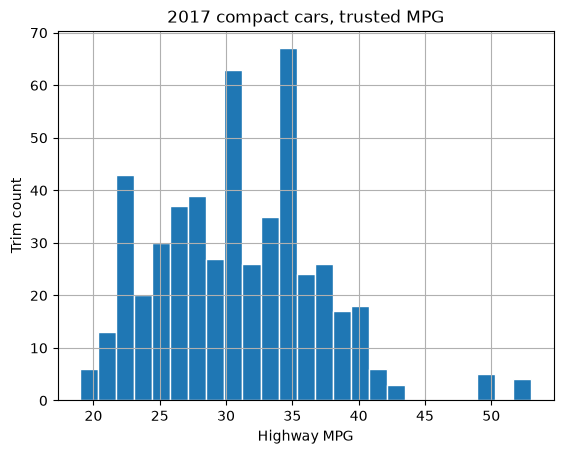

Rows per make + model:


trims
make          model                    
Acura         ILX                     6
              NSX                     1
Audi          A3                     12
              Q3                      6
              R8                      2
              S3                      2
              TT                      2
              TTS                     1
BMW           2 Series                8
              M2                      1
              X1                      2
Buick         Encore                 10
Cadillac      ATS Coupe               7
              ATS-V                   2
Chevrolet     City Express            2
              Corvette               24
              Cruze                   3
              Equinox                 7
              Sonic                  10
              Spark                   6
              Trax                    6
Dodge         Viper                   4
FIAT          124 Spider              3
              500                     6
              500L                    3
              500X                    6
Ford          C-Max Hybrid            2
              Escape                  5
              Fiesta                  7
              Focus                   7
              Focus RS                1
              Focus ST                1
              Transit Connect         9
GMC           Terrain                 9
Honda         Civic                  13
              Fit                     6
              HR-V                    8
Hyundai       Elantra                 7
              Elantra GT              2
              Tucson                  8
Infiniti      Q50                     2
Kia           Forte                   8
              Rio                     6
              Sportage                6
Land Rover    Range Rover Evoque      8
Lexus         CT 200h                 1
Lincoln       MKC                     8
Lotus         Evora 400               1
Mazda         3                       7
              CX-3                    6
Mercedes-Benz AMG GT                  2
              GLA-Class               3
              SL-Class                4
              SLC-Class               2
Mitsubishi    Lancer                  5
              Mirage                  5
              Mirage G4               3
              Outlander Sport         8
Nissan        370Z                   17
              Frontier               22
              Juke                   10
              NV200                   2
              Versa                   5
              Versa Note              4
Porsche       718 Cayman              2
              911                    14
Subaru        BRZ                     4
              Crosstrek               4
              Impreza                 6
              WRX                     7
Toyota        86                      2
              Corolla                 9
              Corolla iM              2
              Prius                   6
              Prius Prime             3
              Tacoma                 27
              Yaris                   7
              Yaris iA                2
Volkswagen    Beetle                  7
              Golf                    4
              Golf Alltrack           5
              Golf GTI               10
              Golf R                  4
              Golf SportWagen         4
              Tiguan                  8

Model sample: n=85, mean=31.685
Model t-test: TtestResult(statistic=np.float64(2.5773313510555917), pvalue=np.float64(0.005851341042610617), df=np.int64(84))


In [9]:
compact2017 = cars2017.loc[cars2017.vehicle_size.eq("Compact") & cars2017.mpg_trusted]
compact_mpg = compact2017.highway_mpg_trusted
trim_test = stats.ttest_1samp(compact_mpg, popmean=30, alternative="greater")
print(f"Trim sample: n={len(compact_mpg)}, mean={compact_mpg.mean():.3f}, skew={compact_mpg.skew():.3f}")
print("Trim t-test:", trim_test)
compact_mpg.hist(bins=25, edgecolor="white")
plt.xlabel("Highway MPG")
plt.ylabel("Trim count")
plt.title("2017 compact cars, trusted MPG")
plt.show()
model_counts = compact2017.groupby(["make", "model"]).size()
print("Rows per make + model:")
with pd.option_context("display.max_rows", None):
    display(model_counts.to_frame("trims"))
model_mpg = compact2017.groupby(["make", "model"]).highway_mpg_trusted.mean()
model_test = stats.ttest_1samp(model_mpg, popmean=30, alternative="greater")
print(f"Model sample: n={len(model_mpg)}, mean={model_mpg.mean():.3f}")
print("Model t-test:", model_test)


**Answer:** H₀: the population mean highway MPG of 2017 compacts is at most 30 (tested at the boundary μ = 30); Hₐ: μ > 30, a one-sided test because marketing specifically claims “over 30.” The 509 trusted trims have mean 30.88 and a mildly right-skewed distribution (skew 0.58), so the large sample supports a t approximation, but correlated trims weaken independence; the trim test gives t = 3.285 and p = 0.000546, rejecting H₀ at 0.05. Averaging within make + model leaves 85 models with mean 31.69, t = 2.577 and p = 0.00585, still supporting a mean above 30; I trust this model-level check more because it reduces repeated-trim weighting, although it targets the equally weighted model mean and does not establish independence between models or a sales-weighted marketplace average.


### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [10]:
trans = clean.loc[clean.transmission_type.isin(["AUTOMATIC", "MANUAL"])]
all_trans_prices = trans.groupby("transmission_type").msrp.agg(["count", "median"])
display(all_trans_prices)
print("Model years by transmission:")
display(trans.groupby("transmission_type").year.agg(["count", "mean", "median", "min", "max"]))
print("Share of each transmission from before 2015:")
display(trans.groupby("transmission_type").older_price_flag.mean())
recent = trans.loc[trans.year.between(2015, 2017)]
recent_trans_prices = recent.groupby("transmission_type").msrp.agg(["count", "median"])
display(recent_trans_prices)
print("Recent median MSRP within each vehicle size:")
recent_size_medians = recent.pivot_table(index="vehicle_size", columns="transmission_type", values="msrp", aggfunc="median")
display(recent_size_medians)
compacts = recent.loc[recent.vehicle_size.eq("Compact")]
auto = compacts.loc[compacts.transmission_type.eq("AUTOMATIC"), "msrp"].dropna()
manual = compacts.loc[compacts.transmission_type.eq("MANUAL"), "msrp"].dropna()
manual_test = stats.mannwhitneyu(auto, manual, alternative="two-sided")
print(f"Recent compacts: auto n={len(auto)}, median=${auto.median():,.0f}; manual n={len(manual)}, median=${manual.median():,.0f}")
print("Mann-Whitney U:", manual_test)
# Show the effect of the cleaning choice on the naive comparison.
print("Medians if the suspect $2,000 floor were retained:")
display(trans.groupby("transmission_type").msrp_raw.median())


,count,median
transmission_type,,
AUTOMATIC,7635,33620.0
MANUAL,2184,21875.0


Model years by transmission:


,count,mean,median,min,max
transmission_type,,,,,
AUTOMATIC,7928,2011.843340,2015.0,1990,2017
MANUAL,2633,2006.475503,2008.0,1990,2017


Share of each transmission from before 2015:


transmission_type
AUTOMATIC    0.431004
MANUAL       0.691227
Name: older_price_flag, dtype: float64

,count,median
transmission_type,,
AUTOMATIC,4511,37065.0
MANUAL,813,26905.0


Recent median MSRP within each vehicle size:


transmission_type,AUTOMATIC,MANUAL
vehicle_size,,
Compact,25995.0,25860.0
Large,44400.0,38395.0
Midsize,37980.0,26920.0


Recent compacts: auto n=1119, median=$25,995; manual n=589, median=$25,860
Mann-Whitney U: MannwhitneyuResult(statistic=np.float64(317261.0), pvalue=np.float64(0.20483161191397048))
Medians if the suspect $2,000 floor were retained:


transmission_type
AUTOMATIC    33007.5
MANUAL       19385.0
Name: msrp_raw, dtype: float64

**Answer:** Pooled valid-price medians are $33,620 automatic vs $21,875 manual, but manuals are older (median year 2008 vs 2015; 69.12% vs 43.10% pre-2015), so the naive gap is confounded. For 2015–2017, medians are $37,065 vs $26,905 overall; by size they are Compact $25,995 vs $25,860, Large $44,400 vs $38,395, and Midsize $37,980 vs $26,920, while the compact Mann–Whitney test gives U = 317,261 and p = 0.2048, insufficient evidence of a distribution difference at 0.05 (not proof of equality or a test solely of medians when distribution shapes differ). To the sales rep: “Manuals look cheaper overall, but comparable recent compacts differ by only $135 in median price, so recommend specific affordable models rather than transmission alone”; trim dependence and remaining differences in brand/equipment also limit inference.


### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [11]:
four = clean.loc[clean.number_of_doors.eq(4), "highway_mpg_trusted"].dropna().to_numpy()
two = clean.loc[clean.number_of_doors.eq(2), "highway_mpg_trusted"].dropna().to_numpy()
welch = stats.ttest_ind(four, two, equal_var=False)
mpg_difference = four.mean() - two.mean()
print(f"4-door n={len(four)}, mean={four.mean():.4f}; 2-door n={len(two)}, mean={two.mean():.4f}")
print(f"Difference={mpg_difference:.4f} MPG; Welch t={welch.statistic:.4f}, p={welch.pvalue:.6g}")
miles, price_per_gallon = 12000, 3.50
cost_four = miles * price_per_gallon / four.mean()
cost_two = miles * price_per_gallon / two.mean()
annual_saving = cost_two - cost_four
print(f"At group mean MPG: 4-door ${cost_four:,.2f}/yr; 2-door ${cost_two:,.2f}/yr; saving ${annual_saving:,.2f}/yr")
# Averaging individual fuel costs differs because 1/mean(MPG) != mean(1/MPG).
mean_cost_saving = np.mean(miles * price_per_gallon / two) - np.mean(miles * price_per_gallon / four)
print(f"Mean of individual fuel costs: saving ${mean_cost_saving:,.2f}/yr")
n_sims, hits = 1000, 0
for _ in range(n_sims):
    sampled_four = rng.choice(four, 30, replace=False)
    sampled_two = rng.choice(two, 30, replace=False)
    hits += stats.ttest_ind(sampled_four, sampled_two, equal_var=False).pvalue < 0.05
sig_fraction = hits / n_sims
print(f"Significant small-sample tests: {hits}/{n_sims} = {sig_fraction:.1%}")


4-door n=7894, mean=26.8054; 2-door n=2873, mean=25.2565
Difference=1.5489 MPG; Welch t=11.9340, p=2.00832e-32
At group mean MPG: 4-door $1,566.85/yr; 2-door $1,662.94/yr; saving $96.09/yr
Mean of individual fuel costs: saving $108.21/yr


Significant small-sample tests: 150/1000 = 15.0%


**Answer:** The 7,894 four-door records average 26.81 highway MPG versus 25.26 for 2,873 two-door records, a 1.55-MPG difference with Welch p = 2.01 × 10⁻³², which is very unlikely under an equal-means model with independent observations. At 12,000 highway miles and $3.50/gallon, cars at those group mean efficiencies differ by about $96.09/year ($108.21 when averaging each trim's modeled fuel cost); only 150/1,000 simulations with 30 cars per group were significant, showing how sample size affects detection. I would avoid the proposed ad and say “In this historical trim dataset, four-door cars averaged about 1.5 more highway MPG, roughly $96/year at our assumed mileage and fuel price,” because door count is not randomized, body style/engine/year can confound the comparison, related trims undermine independence, and real driving includes city miles.


---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Manual cars have a lower median listed price overall ($21,875 vs $33,620), but they are older and differently sized, so this does not show that manual transmission itself lowers prices. Among 2015–2017 compact cars, the medians are only $135 apart ($25,860 manual vs $25,995 automatic), and our comparison does not provide strong evidence of different price distributions. Recommend budget shoppers specific models with comparable age, size and features rather than relying on transmission alone. For a typical-price display, use the median of $31,870 instead of the $44,789 mean because a small number of expensive luxury trims pull the mean upward. These are historical, unweighted trim records from 1990–2017 rather than current sale transactions, and missing/censored prices plus repeated models limit how well the results describe today's buyers.


---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

n=10378; Pearson raw=0.6495; Pearson log-price=0.6983; Spearman=0.8220


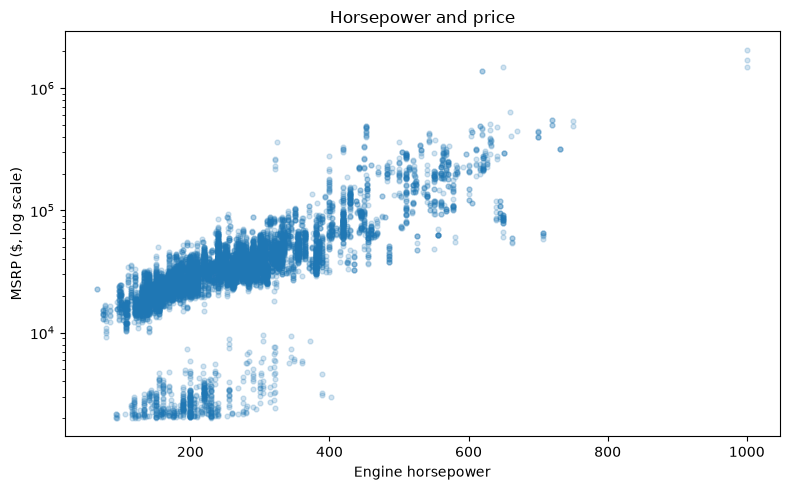

In [12]:
hp_prices = clean[["engine_hp", "msrp"]].dropna()
pearson_raw = stats.pearsonr(hp_prices.engine_hp, hp_prices.msrp)
pearson_log = stats.pearsonr(hp_prices.engine_hp, np.log10(hp_prices.msrp))
spearman = stats.spearmanr(hp_prices.engine_hp, hp_prices.msrp)
print(f"n={len(hp_prices)}; Pearson raw={pearson_raw.statistic:.4f}; Pearson log-price={pearson_log.statistic:.4f}; Spearman={spearman.statistic:.4f}")
plt.figure(figsize=(8, 5))
plt.scatter(hp_prices.engine_hp, hp_prices.msrp, alpha=0.2, s=12)
plt.yscale("log")
plt.xlabel("Engine horsepower")
plt.ylabel("MSRP ($, log scale)")
plt.title("Horsepower and price")
plt.tight_layout()
plt.show()


**Stretch S1 answer:** Pearson correlation is 0.650 using raw prices and 0.698 using log10 prices; Spearman is 0.822. Logging reduces the leverage of exceptionally expensive cars and makes the relationship more linear, while Spearman captures rank-based monotonic association rather than a straight-line relation on the original scale. None establishes causation: luxury branding, engine technology and vehicle class can influence both horsepower and price; these complete cases also omit missing HP disproportionately found in electric cars.


### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [13]:
size_transmission = pd.crosstab(recent.vehicle_size, recent.transmission_type)
chi2, chi_p, dof, expected = stats.chi2_contingency(size_transmission)
display(size_transmission)
print(f"Chi-square={chi2:.3f}, df={dof}, p={chi_p:.6g}; smallest expected count={expected.min():.2f}")
print("Transmission shares within size:")
display(size_transmission.div(size_transmission.sum(axis=1), axis=0))


transmission_type,AUTOMATIC,MANUAL
vehicle_size,,
Compact,1119,589
Large,1473,26
Midsize,1919,198


Chi-square=756.929, df=2, p=4.3147e-165; smallest expected count=228.90
Transmission shares within size:


transmission_type,AUTOMATIC,MANUAL
vehicle_size,,
Compact,0.655152,0.344848
Large,0.982655,0.017345
Midsize,0.906471,0.093529


**Stretch S2 answer:** χ² = 756.929 with 2 degrees of freedom and p = 4.31 × 10⁻¹⁶⁵; all expected counts exceed 5. Manuals represent 34.5% of recent compacts, 9.4% of midsize trims and 1.7% of large trims, so size and transmission are associated, helping explain why Q6's pooled price comparison differs from the compact comparison. Related trims still weaken independence; association does not prove transmission changes size or price.
